# Quickstart: Semantic Isotropy

In [1]:
import numpy as np
from datasets import load_dataset

from semantic_isotropy.llm.api import *
from semantic_isotropy.metrics.isotropy import get_embedding_density, get_vn, get_Z

import matplotlib.pyplot as plt

## Load Dataset from HuggingFace

In [2]:
dataset = 'triviaqa'# or 'fsbio'
models = ["openai", "meta", "msft"]
data_files = {"openai": f"data/{dataset}/*openai*.jsonl", "meta_llama3.1": f"data/{dataset}/*meta*.jsonl", "msft_phi3.5": f"data/{dataset}/*msft*.jsonl"}
triviaqa = load_dataset("dhrupadb/SegmentScore", data_files=data_files)

# The library will download the files and load them into a DatasetDict object
print(triviaqa)

DatasetDict({
    openai: Dataset({
        features: ['index', 'idx_cat', 'entity', 'entity_page_idx', 'responses'],
        num_rows: 1000
    })
    meta_llama3.1: Dataset({
        features: ['index', 'idx_cat', 'entity', 'entity_page_idx', 'responses'],
        num_rows: 1000
    })
    msft_phi3.5: Dataset({
        features: ['index', 'idx_cat', 'entity', 'entity_page_idx', 'responses'],
        num_rows: 1000
    })
})


In [3]:
entity = triviaqa['openai'][0]['entity']
responses = triviaqa['openai'][0]['responses']

## Generate your own responses

In [4]:
from longform_uq.prompts.oeq import *

In [5]:
entity = "Write a short essay on \'Joan of Arc\'"
k = 10
prompts = create_prompts([entity]*k, 100)

In [6]:
print(prompts[0])


You are a helpful assistant that generates responses to open-ended questions.
Adhere strictly to the instructions and formatting requirements in the prompt, ensuring accuracy, consistency and correctness of formatting and content.


    You are given a open ended question in <question> tags.
    Write a response of approximately 100 words to the question. Be sure to include any topics or details you deem relevant.
    Do not include any other clarifications or context, only the response to the question.
    Start your response with the <response> tag and end with the </response> tag. No other tags should be present in the answer.
    Each tag should appear once and once only. No other tags should be present in the answer.

    <question>Write a short essay on 'Joan of Arc'</question>
    


In [7]:
responses = [chat_api(prompt, 'openai', model='gpt-4.1-mini') for prompt in prompts]
responses = [{'response': response['response'].replace('<response>', '').replace('</response', '')} for response in responses]

In [8]:
responses[0]['response']

"Joan of Arc, born around 1412 in Domrémy, France, is a national heroine and saint known for her pivotal role during the Hundred Years' War. Claiming divine guidance, she inspired French troops and led several successful military campaigns, notably lifting the Siege of Orléans in 1429. Joan’s courage and faith galvanized French resistance against English forces, contributing significantly to Charles VII’s coronation as king. Captured by the Burgundians and handed over to the English, she was tried for heresy and burned at the stake in 1431 at just 19 years old. Joan of Arc remains a symbol of bravery, faith, and patriotism in French history.>"

## Calculate Embedding and Isotropy Score 

### Using Open Weight Model

In [9]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, AutoConfig

In [10]:
embedding_model = "nomic-ai/nomic-embed-text-v1"
device = "mps" # cpu or cuda:0 as appropriate for your infrastructure

In [11]:
config = AutoConfig.from_pretrained(embedding_model, output_hidden_states=True, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(embedding_model, trust_remote_code=True)
tokenizer.add_special_tokens({'pad_token': tokenizer.special_tokens_map.get('pad_token', tokenizer.eos_token)})

# Standard single device loading
model = AutoModel.from_pretrained(
    embedding_model,
    trust_remote_code=True,
    config=config
)
_ = model.to(device)

<All keys matched successfully>


In [12]:
pooled_vectors, _ = get_embedding_density(entity, responses, model, tokenizer, model_name="nomic-text-v1")

In [13]:
X = pooled_vectors
print(f"Isotropy Score: {get_vn(X)/np.log(X.shape[0])}")

Isotropy Score: 0.032198560689445675


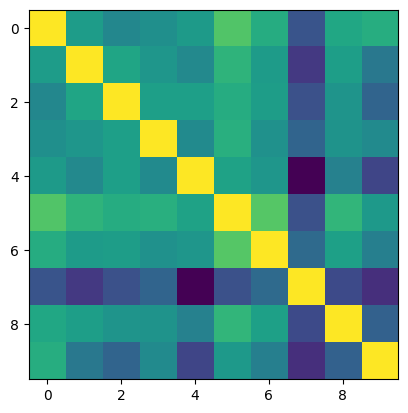

In [15]:
plt.imshow(get_Z(X), cmap='viridis', interpolation='nearest') # Plot the Cosine Kernel
plt.show()

### Using API Model

In [16]:
pooled_vectors, _ = get_embedding_density(entity, responses, None, None, model_name="gemini-embedding-001")

In [17]:
X = pooled_vectors
print(f"Isotropy Score: {get_vn(X)/np.log(X.shape[0])}")

Isotropy Score: 0.07200531154421895


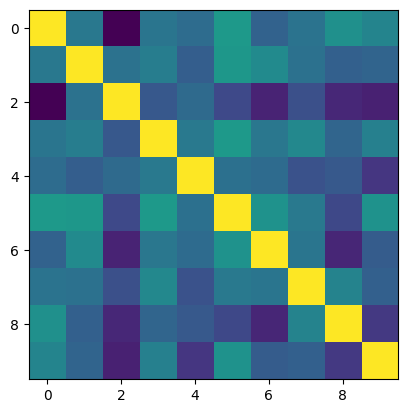

In [18]:
plt.imshow(get_Z(X), cmap='viridis', interpolation='nearest')
plt.show()